<a href="https://colab.research.google.com/github/DylanSanchz/Quantum-Circuits/blob/main/Algoritmo_de_Simon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00


In [ ]:
pip install 'qiskit [visualization]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=419172d16d6c5bdde809db6bbd6bbefc36aa94b848ef30c0b5b5232ff3b759fa
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
## IMPORTAMOS LIBRERIAS

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt



SELECIONAMOS LLAVE

In [ ]:
## ELEGIMOS LA LLAVE

s = "010"
# s = "011"
# s = "100"
# s = "101"
# s = "110"

n = len(s)



Definimos el circuito

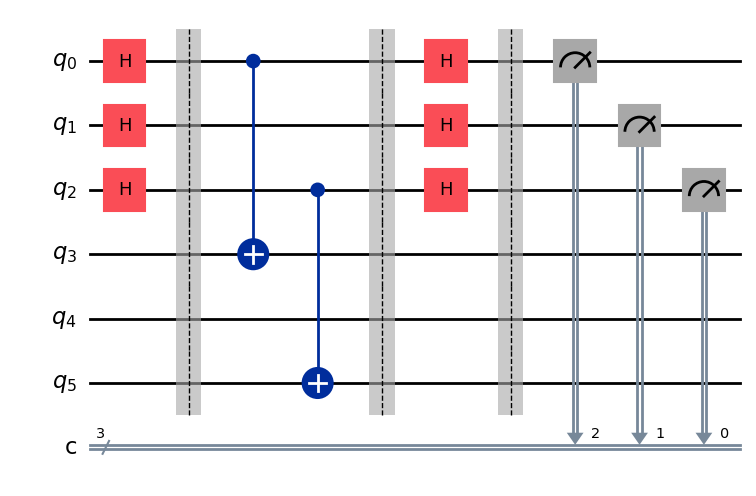

In [ ]:
# Criamos o circuito:
# n qubits de entrada + n qubits de saída
# n bits clássicos para medir apenas o registrador de entrada
qc = QuantumCircuit(2*n, n)

# 1) Aplicamos Hadamard nos qubits de entrada
qc.h(range(n))
qc.barrier()

# 2) Construção do oráculo de Simon
# Escolhemos a primeira posição onde s tem valor 1
p = s.index("1")

for i, bit in enumerate(s):
    if i == p:
        continue

    # Copiamos x_i para o registrador de saída
    qc.cx(i, n + i)

    # Se s_i = 1, também misturamos x_p nessa saída
    if bit == "1":
        qc.cx(p, n + i)

qc.barrier()

# 3) Aplicamos Hadamard novamente nos qubits de entrada
qc.h(range(n))
qc.barrier()

# 4) Medição dos qubits de entrada
# Medimos de forma que o histograma apareça na ordem q0 q1 q2
for i in range(n):
    qc.measure(i, n - 1 - i)

qc.draw("mpl", filename="quantum_circuit.png")

Resultados

Chave secreta s = 010
Resultados: {'000': 254, '001': 256, '100': 249, '101': 265}
     ┌───┐ ░            ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░───■────────░─┤ H ├─░─┤M├──────
     ├───┤ ░   │        ░ ├───┤ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───┼────────░─┤ H ├─░──╫─┤M├───
     ├───┤ ░   │        ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───┼────■───░─┤ H ├─░──╫──╫─┤M├
     └───┘ ░ ┌─┴─┐  │   ░ └───┘ ░  ║  ║ └╥┘
q_3: ──────░─┤ X ├──┼───░───────░──╫──╫──╫─
           ░ └───┘  │   ░       ░  ║  ║  ║ 
q_4: ──────░────────┼───░───────░──╫──╫──╫─
           ░      ┌─┴─┐ ░       ░  ║  ║  ║ 
q_5: ──────░──────┤ X ├─░───────░──╫──╫──╫─
           ░      └───┘ ░       ░  ║  ║  ║ 
c: 3/══════════════════════════════╩══╩══╩═
                                   2  1  0 


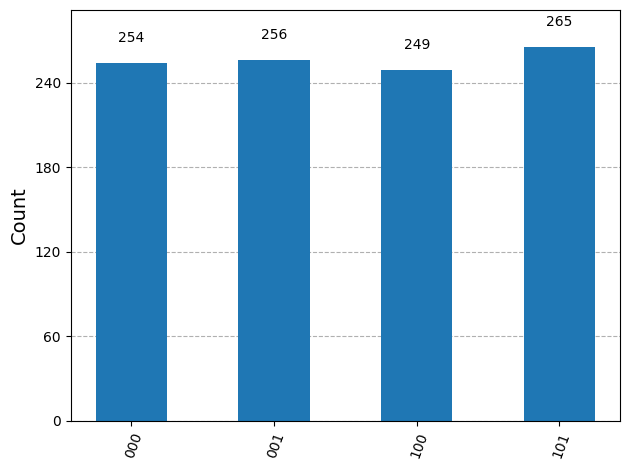

In [ ]:
# Simulador
simulator = AerSimulator()
compiled = transpile(qc, simulator)

result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

print("Chave secreta s =", s)
print("Resultados:", counts)

# Mostrar circuito em texto
print(qc.draw())

# Mostrar histograma
hist = plot_histogram(counts)
display(hist)

In [ ]:
# Histograma
plot_histogram(counts)
plt.show()

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# =========================
# Escolha da chave secreta
# Deixe apenas uma descomentada
# =========================
s = "010"
# s = "011"
# s = "100"
# s = "101"
# s = "110"

n = len(s)

# Criamos o circuito:
# n qubits de entrada + n qubits de saída
# n bits clássicos para medir apenas o registrador de entrada
qc = QuantumCircuit(2*n, n)

# 1) Aplicamos Hadamard nos qubits de entrada
qc.h(range(n))
qc.barrier()

# 2) Construção do oráculo de Simon
# Escolhemos a primeira posição onde s tem valor 1
p = s.index("1")

for i, bit in enumerate(s):
    if i == p:
        continue

    # Copiamos x_i para o registrador de saída
    qc.cx(i, n + i)

    # Se s_i = 1, também misturamos x_p nessa saída
    if bit == "1":
        qc.cx(p, n + i)

qc.barrier()

# 3) Aplicamos Hadamard novamente nos qubits de entrada
qc.h(range(n))
qc.barrier()

# 4) Medição dos qubits de entrada
# Medimos de forma que o histograma apareça na ordem q0 q1 q2
for i in range(n):
    qc.measure(i, n - 1 - i)

# 5) Executamos no simulador
simulator = AerSimulator()
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

# 6) Mostramos os resultados
print("Chave secreta s =", s)
print("Resultados:", counts)

# Desenho do circuito
print(qc.draw())

# Histograma
plot_histogram(counts)
plt.show()

Chave secreta s = 010
Resultados: {'100': 278, '000': 250, '001': 257, '101': 239}
     ┌───┐ ░            ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░───■────────░─┤ H ├─░─┤M├──────
     ├───┤ ░   │        ░ ├───┤ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───┼────────░─┤ H ├─░──╫─┤M├───
     ├───┤ ░   │        ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───┼────■───░─┤ H ├─░──╫──╫─┤M├
     └───┘ ░ ┌─┴─┐  │   ░ └───┘ ░  ║  ║ └╥┘
q_3: ──────░─┤ X ├──┼───░───────░──╫──╫──╫─
           ░ └───┘  │   ░       ░  ║  ║  ║ 
q_4: ──────░────────┼───░───────░──╫──╫──╫─
           ░      ┌─┴─┐ ░       ░  ║  ║  ║ 
q_5: ──────░──────┤ X ├─░───────░──╫──╫──╫─
           ░      └───┘ ░       ░  ║  ║  ║ 
c: 3/══════════════════════════════╩══╩══╩═
                                   2  1  0 


Chave secreta s = 010
Resultados: {'101': 263, '000': 255, '100': 253, '001': 253}
     ┌───┐ ░            ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░───■────────░─┤ H ├─░─┤M├──────
     ├───┤ ░   │        ░ ├───┤ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───┼────────░─┤ H ├─░──╫─┤M├───
     ├───┤ ░   │        ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───┼────■───░─┤ H ├─░──╫──╫─┤M├
     └───┘ ░ ┌─┴─┐  │   ░ └───┘ ░  ║  ║ └╥┘
q_3: ──────░─┤ X ├──┼───░───────░──╫──╫──╫─
           ░ └───┘  │   ░       ░  ║  ║  ║ 
q_4: ──────░────────┼───░───────░──╫──╫──╫─
           ░      ┌─┴─┐ ░       ░  ║  ║  ║ 
q_5: ──────░──────┤ X ├─░───────░──╫──╫──╫─
           ░      └───┘ ░       ░  ║  ║  ║ 
c: 3/══════════════════════════════╩══╩══╩═
                                   2  1  0 


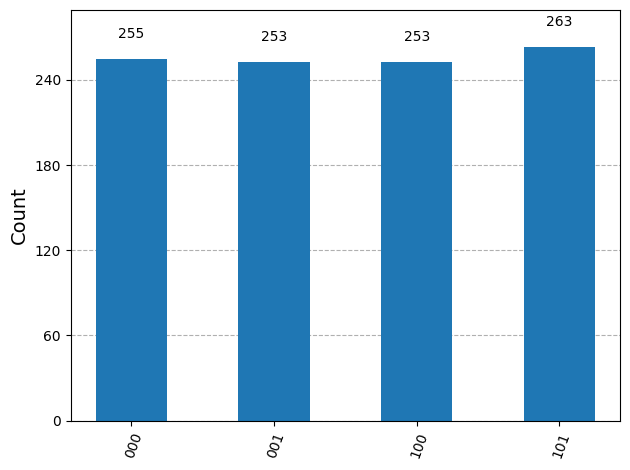

In [ ]:
# Simulador
simulator = AerSimulator()
compiled = transpile(qc, simulator)

result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

print("Chave secreta s =", s)
print("Resultados:", counts)

# Mostrar circuito em texto
print(qc.draw())

# Mostrar histograma
hist = plot_histogram(counts)
display(hist)